In [223]:
import itertools
import logging
from pathlib import Path
from typing import Any, Callable, Sequence

import matplotlib.pyplot as plt
import mlflow
import nico2_lib as n2l
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc
import seaborn as sns
from experiment import Celltype, Dataset, Model, NumericArray, Result, Sample
from numpy import number
from sqlalchemy import event
from sqlalchemy.engine import Engine
from sqlmodel import Session, create_engine, select
import scipy
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

In [2]:
DataEntries = list[dict[str, Any]]

In [ ]:
exp_name = "Default"
benchmark_experiment = mlflow.get_experiment_by_name(exp_name)
if not benchmark_experiment:
    raise ValueError(f"Experiment '{exp_name}' not found.")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
if runs.empty:
    raise RuntimeError(f"No runs found in experiment '{exp_name}'.")
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]
logger.info(f"Using run_id: {last_run_id}")
logger.info("Downloading 'database.db'...")
database_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="database.db"
)
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

In [10]:
database_path = "/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-03-11T09-44-10Z/database.db"
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

INFO: Local path: /Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-03-11T09-44-10Z/database.db
INFO: Database engine initialized.


In [ ]:
import re


def sanitize_filename(name: str) -> str:
    return re.sub(r'[/\\?%*:|"<>]', "_", name)


In [ ]:
import matplotlib.pyplot as plt


def plot_embedding(
    results: Sequence[tuple[Result, Model]], celltype: Celltype, sample: Sample
) -> None:
    n_rows = len(results)
    max_latents = max(r.celltype_model_embedding_query.shape[1] for r, _ in results)

    # Create the figure with subfigures for each latent dimension
    fig = plt.figure(figsize=(max_latents * 4, n_rows * 3), dpi=300)
    subfigs = fig.subfigures(n_rows, max_latents, wspace=0.1, hspace=0.1)

    query_umap = celltype.query_umap_embedding
    reference_umap = celltype.reference_umap_embedding

    for r_idx, (res, model) in enumerate(results):
        q_latents = res.celltype_model_embedding_query
        r_latents = res.celltype_model_embedding_reference
        k_current = q_latents.shape[1]

        for latent_idx in range(max_latents):
            subfig = subfigs[r_idx, latent_idx]

            # Style the subfigure container
            subfig.set_facecolor("#fcfcfc")
            subfig.suptitle(f"Latent {latent_idx}", fontsize=10, fontweight="bold")

            if latent_idx < k_current:
                # Create axes within the subfigure for the pair
                ax_q, ax_r = subfig.subplots(1, 2)

                # Plot Query
                ax_q.scatter(
                    *query_umap.T,
                    c=q_latents[:, latent_idx],
                    cmap="plasma",
                    s=2,
                    alpha=0.7,
                )
                ax_q.set_title("Query", fontsize=8)
                ax_q.axis("off")

                # Plot Reference
                ax_r.scatter(
                    *reference_umap.T,
                    c=r_latents[:, latent_idx],
                    cmap="plasma",
                    s=2,
                    alpha=0.7,
                )
                ax_r.set_title("Ref", fontsize=8)
                ax_r.axis("off")

                if latent_idx == 0:
                    ax_q.text(
                        -0.2,
                        0.5,
                        f"{model.name}\n(k={k_current})",
                        transform=ax_q.transAxes,
                        rotation=90,
                        va="center",
                        fontweight="bold",
                    )
            else:
                # Hide empty subfigures
                subfig.axis("off")

    ds_name = getattr(celltype.dataset, "name", "Unknown")
    fig.suptitle(
        f"Comparison: {celltype.name} | Dataset: {ds_name} | Sample: {sample.id_of_sample}",
        fontsize=16,
        y=1.02,
    )
    plt.show()
    # fig_path = f"./plots/{sanitize_filename(celltype.dataset.name)}_{sanitize_filename(celltype.name)}.jpg"
    # plt.savefig(Path(fig_path))

In [ ]:
from itertools import product

with Session(engine) as session:
    datasets = session.exec(
        select(Dataset).where(Dataset.name == "mouse_intestine_pseudospatial")
    ).all()
    for dataset in datasets:
        celltypes = dataset.celltypes
        samples = dataset.samples
        for celltype, sample in product(celltypes, samples):
            results = session.exec(
                select(Result, Model)
                .join(Model)
                .where(Result.celltype == celltype)
                .where(Result.sample == sample)
            ).all()
            plot_embedding(results, celltype, sample)

In [201]:
from typing import Callable

import numpy as np


def blabla(
    func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def blabla2(adjacency: NumericArray, embeddings: NumericArray) -> float:
        # 1. Identify non-zero columns (features)
        # We check if the absolute sum of the column is > 0
        non_zero_mask = np.any(embeddings != 0, axis=0)
        valid_features = embeddings[:, non_zero_mask]

        # 2. Guard against the case where NO features are non-zero
        if valid_features.shape[1] == 0:
            return 0.0

        # 3. Compute only for valid latent features
        scores = [func(adjacency, feature) for feature in valid_features.T]

        return float(np.mean(scores))

    return blabla2


def compute_dirichlet_energy(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Measures smoothness: E = x.T @ L @ x.
    Low energy = High coherence.
    """
    # Degree matrix (sum of rows)
    d = np.sum(adjacency, axis=1)
    # L = D - W
    # Energy = sum over edges of (xi - xj)^2 * wij
    # For a single vector, this is equivalent to:
    sq_diff = (feature[:, np.newaxis] - feature[np.newaxis, :]) ** 2
    energy = 0.5 * np.sum(adjacency * sq_diff)
    return float(energy)


def compute_multivariate_geary(adjacency: np.ndarray, embeddings: np.ndarray) -> float:
    """
    A direct multivariate version of Geary's C.
    Computes Euclidean distance in embedding space weighted by graph adjacency.
    """
    n, d = embeddings.shape
    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    # Variance normalization (denominator)
    # We sum the variance of each feature column
    variance_sum = np.sum(np.var(embeddings, axis=0))
    if variance_sum == 0:
        return 0.0

    # Calculate weighted squared Euclidean distances between all neighbors
    # Using a memory-efficient approach for large n:
    # dist(i,j)^2 = ||xi||^2 + ||xj||^2 - 2<xi, xj>
    norms = np.sum(embeddings**2, axis=1)
    dist_sq = (
        norms[:, np.newaxis]
        + norms[np.newaxis, :]
        - 2 * np.dot(embeddings, embeddings.T)
    )

    numerator = np.sum(adjacency * dist_sq)
    denominator = 2 * w_sum * variance_sum

    return float(((n - 1) * numerator) / (n * denominator))


def compute_persistence_quality(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Measures 'Topological Signal-to-Noise'.
    Higher value = feature has a clear, non-random structure over the manifold.
    """
    raise (NotImplementedError())
    from gtda.homology import VietorisRipsPersistence

    # We treat the feature as a 1D signal over the graph coordinates
    # For simplicity, we look at the 'H0' (connectivity) persistence
    # Reshape for Giotto-TDA: (n_samples, n_points, n_dimension)
    data = feature.reshape(1, -1, 1)

    vr = VietorisRipsPersistence(homology_dimensions=[0])
    diagrams = vr.fit_transform(data)

    # Calculate lifespans (death - birth)
    lifespans = diagrams[0, :, 1] - diagrams[0, :, 0]

    # Return the sum of significant lifespans (Total Persistence)
    return float(np.sum(lifespans[np.isfinite(lifespans)]))


def compute_lisa_numpy(adjacency: NumericArray, feature: NumericArray) -> float:
    """
    Pure NumPy Local Moran's I.
    Input: (n, n) adjacency, (n,) feature vector.
    """
    # 1. Standardize the feature (z-scores)
    z = (feature - np.mean(feature)) / np.std(feature)

    adjacency = np.asarray(adjacency)
    row_sums = adjacency.sum(axis=1).reshape(-1)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    w_norm = adjacency / row_sums

    spatial_lag = w_norm @ z

    # 3. Local I_i = z_i * sum(w_ij * z_j)
    local_i: NumericArray = z * spatial_lag

    # Return average local coherence
    return float(np.mean(local_i))


def manual_morans_i(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Standard Moran's I: I = (n/W) * (z'Wz / z'z)
    Range: [-1, 1]. > 0 is clustered, < 0 is dispersed.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    w_z = adjacency @ z
    numerator = z @ w_z

    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    return float((n / w_sum) * (numerator / sum_sq_z))


def manual_gearys_c(adjacency: np.ndarray, feature: np.ndarray) -> float:
    """
    Standard Geary's C: C = ((n-1)/2W) * (sum w_ij (xi-xj)^2 / sum (xi-mean)^2)
    Range: [0, 2]. 0 is perfect coherence, 1 is random.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    # Efficient calculation of sum w_ij (xi - xj)^2 using the Graph Laplacian identity
    # numerator = 2 * (x^T D x - x^T W x)
    row_sums = np.asarray(adjacency.sum(axis=1)).reshape(-1)
    weighted_sq_diff = 2 * ((feature**2) @ row_sums - feature @ (adjacency @ feature))

    w_sum = np.sum(row_sums)
    if w_sum == 0:
        return 0.0

    denominator = (2 * w_sum * sum_sq_z) / (n - 1)

    return float(weighted_sq_diff / denominator)


SPATIAL_AUTOCORRELATION_METRIC_REGISTRY: dict[
    str, Callable[[NumericArray, NumericArray], float]
] = {
    "morans_i": blabla(manual_morans_i),
    "gearys_c": blabla(manual_gearys_c),
    "multivariate_geary": compute_multivariate_geary,
    "dirichlet": blabla(compute_dirichlet_energy),
    "lisa_coherence": blabla(compute_lisa_numpy),
    # "topological_persistence": compute_persistence_quality,
}

In [202]:
def make_spatial_autocorrelation_metrics_func(
    metrics: dict[str, Callable[[NumericArray, NumericArray], NumericArray]],
) -> Callable[[Result], DataEntries]:
    def spatial_autocorellation_metrics_func(result: Result) -> DataEntries:
        celltype = result.celltype
        data_entries: DataEntries = []
        for metric_name, metric_func in metrics.items():
            data_entries.extend(
                [
                    {
                        "model_scope": "global",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.query_adjacency_matrix.toarray(),
                            result.global_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "global",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.reference_adjacency_matrix.toarray(),
                            result.global_model_embedding_reference,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.query_adjacency_matrix.toarray(),
                            result.celltype_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": metric_func(
                            celltype.reference_adjacency_matrix.toarray(),
                            result.celltype_model_embedding_reference,
                        ),
                    },
                ]
            )
        return data_entries

    return spatial_autocorellation_metrics_func


In [203]:
def results_to_dataframe(
    results: Sequence[Result],
    func: Callable[[Result], DataEntries],
) -> pl.DataFrame:
    rows: DataEntries = []
    for result in results:
        extracted_results = func(result)
        for extracted_result in extracted_results:
            rows.append(
                {
                    **extracted_result,
                    "dataset_name": result.celltype.dataset.name,
                    "celltype": result.celltype.name,
                    "sample_id": result.sample.id_of_sample,
                    "model_name": result.model.name,
                }
            )
    return pl.DataFrame(rows)


In [ ]:
with Session(engine) as session:
    results = session.exec(select(Result)).all()
    embedding_autocorrelation_df = results_to_dataframe(
        results,
        make_spatial_autocorrelation_metrics_func(
            SPATIAL_AUTOCORRELATION_METRIC_REGISTRY
        ),
    )

2026-03-11 14:23:20,400 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026/03/11 14:23:20 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-03-11 14:23:20,401 INFO sqlalchemy.engine.Engine SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026/03/11 14:23:20 INFO sqlalchemy.engine.Engine: SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026-03-11 14:23:20,402 INFO sqlalchemy.engine.Engine [cached since 1.062e+04s ago] ()


...

2026/03/11 14:23:24 INFO sqlalchemy.engine.Engine: SELECT celltype.id AS celltype_id, celltype.name AS celltype_name, celltype.reference_counts_matrix AS celltype_reference_counts_matrix, celltype.reference_pca_embedding AS celltype_reference_pca_embedding, celltype.reference_umap_embedding AS celltype_reference_umap_embedding, celltype.reference_adjacency_matrix AS celltype_reference_adjacency_matrix, celltype.query_counts_matrix AS celltype_query_counts_matrix, celltype.query_pca_embedding AS celltype_query_pca_embedding, celltype.query_umap_embedding AS celltype_query_umap_embedding, celltype.query_adjacency_matrix AS celltype_query_adjacency_matrix, celltype.n_pcs AS celltype_n_pcs, celltype.n_neighbours AS celltype_n_neighbours, celltype.dataset_id AS celltype_dataset_id 
FROM celltype 
WHERE celltype.id = ?


2026-03-11 14:23:24,035 INFO sqlalchemy.engine.Engine [cached since 1.062e+04s ago] (38,)


2026/03/11 14:23:24 INFO sqlalchemy.engine.Engine: [cached since 1.062e+04s ago] (38,)


2026-03-11 14:23:24,067 INFO sqlalchemy.engine.Engine ROLLBACK


2026/03/11 14:23:24 INFO sqlalchemy.engine.Engine: ROLLBACK


In [ ]:
embedding_autocorrelation_df = embedding_autocorrelation_df.with_columns(
    combined_hue=pl.col("split") + " | " + pl.col("model_scope")
)

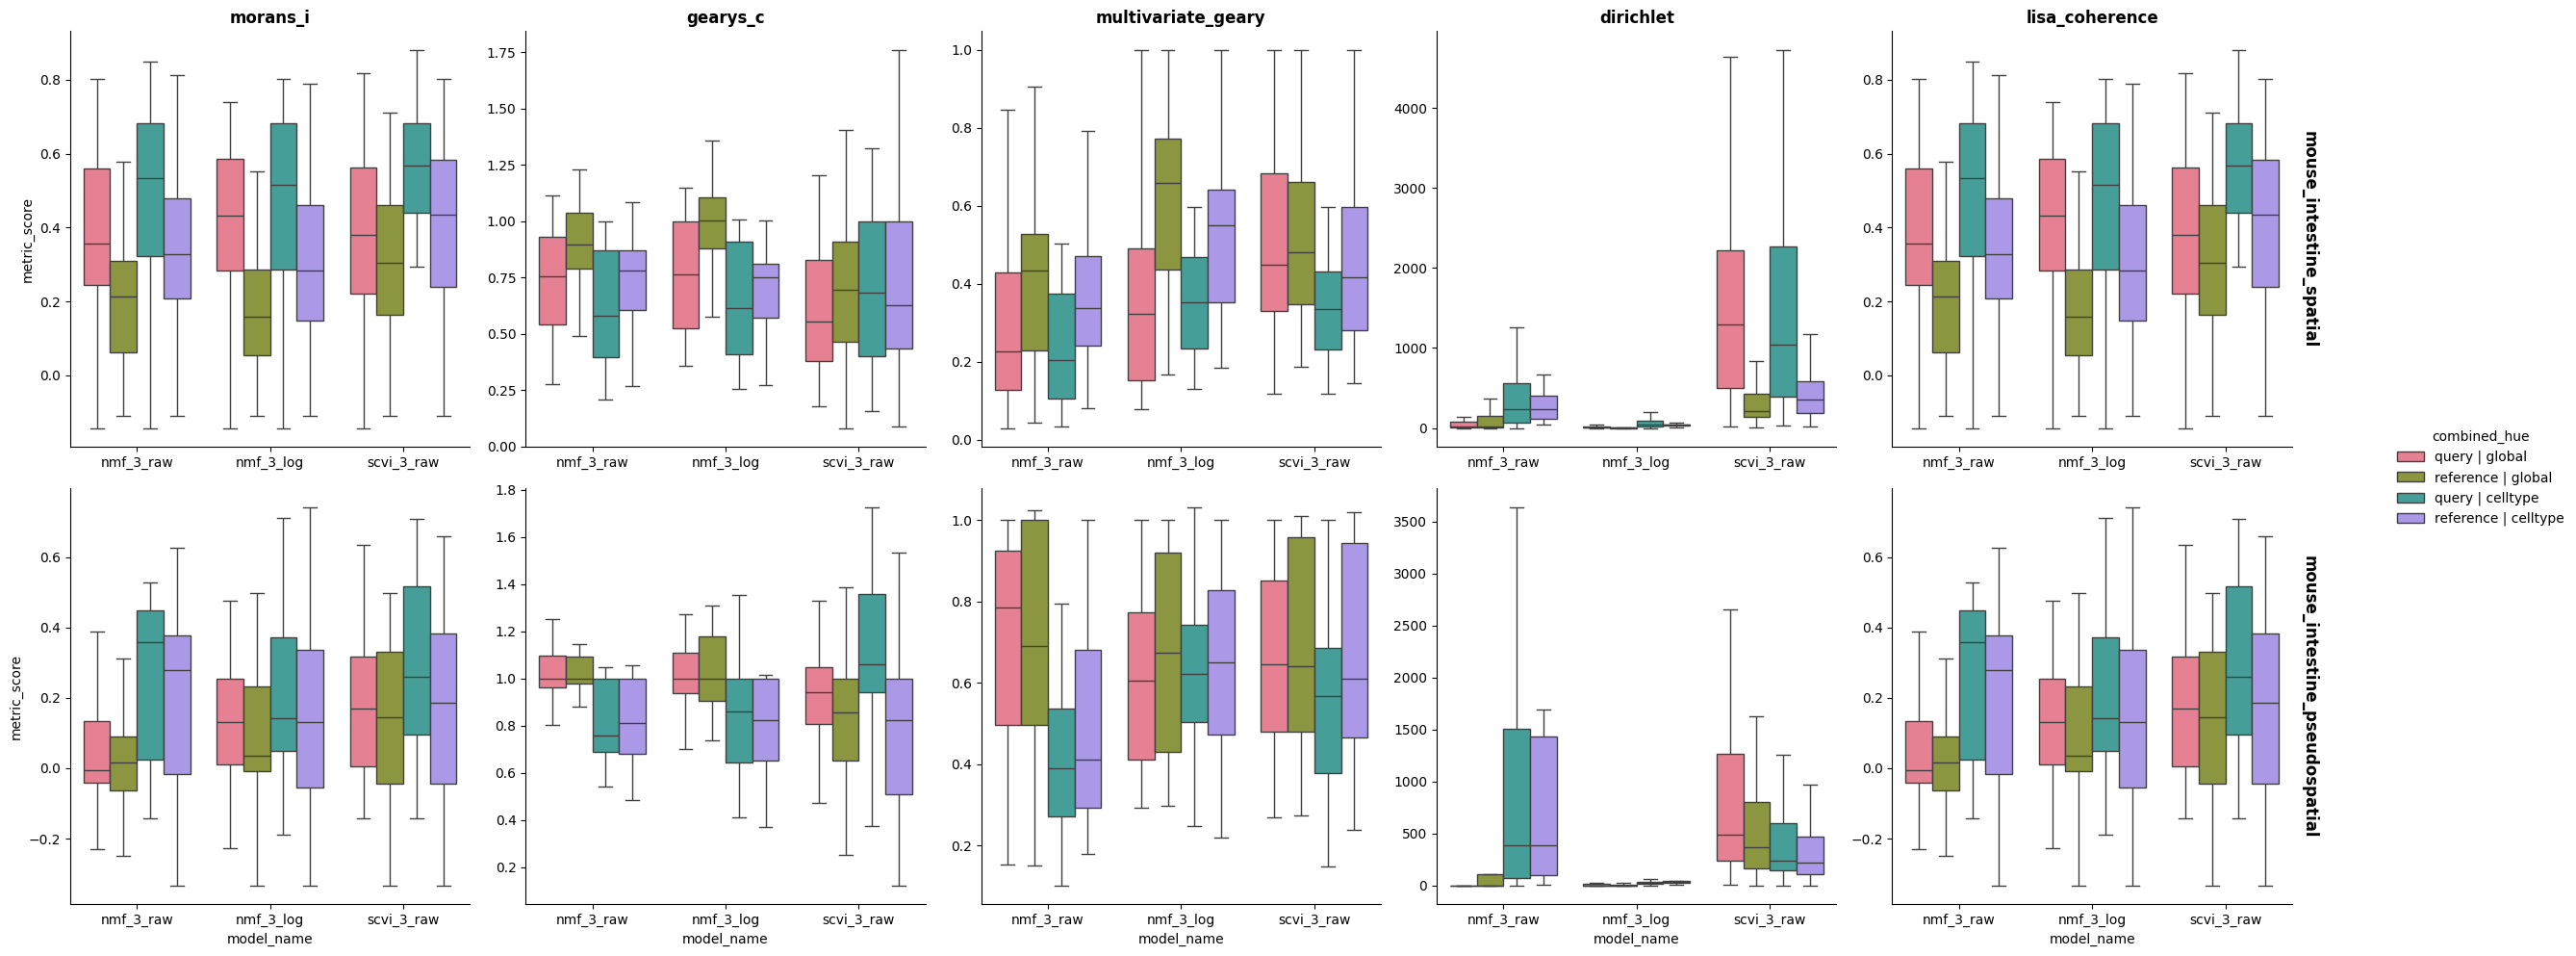

In [ ]:
sns.catplot(
    data=embedding_autocorrelation_df,
    kind="box",
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    col="metric_name",
    row="dataset_name",
    aspect=1,
    sharey=False,
    sharex=False,
    margin_titles=True,
    showfliers=False,
    palette="husl",
).set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
    size=12,
    fontweight="bold",
).savefig("spatial_autocorrelation.svg")

In [134]:
def _create_avg_pairwise_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray], float]:
    """Returns a function that computes the average pairwise metric between feature columns.

    The returned function applies ``metric_fn`` to all unique pairs of columns
    in a 2D array of shape (n_samples, n_features) and returns the mean result.

    Args:
        metric_fn: Function that takes two 1D arrays and returns a float.

    Returns:
        Function that takes a 2D array and returns the average pairwise metric
        across all column pairs."""

    def pairwise_metric_fn(
        features: NumericArray,
    ) -> float:
        eps = 1e-8
        return np.array(
            [
                metric_fn(a + eps, b + eps)
                for a, b in itertools.combinations(features.T, 2)
            ]
        ).mean()

    return pairwise_metric_fn


EMBEDDING_AUTOCORRELATION_METRIC_REGISTRY: dict[
    str, Callable[[NumericArray, NumericArray], float]
] = {
    "pearsonr": n2l.mt.pearson_metric,
    "spearmanr": n2l.mt.spearman_metric,
    "cosine_similarity": n2l.mt.cosine_similarity_metric,
}

In [135]:
def make_embedding_autocorrelation_metrics_func(
    metrics: dict[str, Callable[[NumericArray, NumericArray], float]],
) -> Callable[[Result], DataEntries]:
    def embedding_autocorellation_metrics_func(result: Result) -> DataEntries:
        data_entries: DataEntries = []
        for metric_name, metric_func in metrics.items():
            pairwise_metric_fn = _create_avg_pairwise_metric_fn(metric_func)
            data_entries.extend(
                [
                    {
                        "model_scope": "global",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": pairwise_metric_fn(
                            result.global_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "global",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": pairwise_metric_fn(
                            result.global_model_embedding_reference,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": pairwise_metric_fn(
                            result.celltype_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": pairwise_metric_fn(
                            result.celltype_model_embedding_reference,
                        ),
                    },
                ]
            )
        return data_entries

    return embedding_autocorellation_metrics_func


In [213]:
with Session(engine) as session:
    results = session.exec(select(Result)).all()
    embedding_autocorrelation_df = results_to_dataframe(
        results,
        make_embedding_autocorrelation_metrics_func(
            EMBEDDING_AUTOCORRELATION_METRIC_REGISTRY
        ),
    )

2026-03-11 15:03:35,205 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026/03/11 15:03:35 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-03-11 15:03:35,206 INFO sqlalchemy.engine.Engine SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026/03/11 15:03:35 INFO sqlalchemy.engine.Engine: SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026-03-11 15:03:35,207 INFO sqlalchemy.engine.Engine [cached since 1.304e+04s ago] ()


...

2026/03/11 15:03:38 INFO sqlalchemy.engine.Engine: SELECT celltype.id AS celltype_id, celltype.name AS celltype_name, celltype.reference_counts_matrix AS celltype_reference_counts_matrix, celltype.reference_pca_embedding AS celltype_reference_pca_embedding, celltype.reference_umap_embedding AS celltype_reference_umap_embedding, celltype.reference_adjacency_matrix AS celltype_reference_adjacency_matrix, celltype.query_counts_matrix AS celltype_query_counts_matrix, celltype.query_pca_embedding AS celltype_query_pca_embedding, celltype.query_umap_embedding AS celltype_query_umap_embedding, celltype.query_adjacency_matrix AS celltype_query_adjacency_matrix, celltype.n_pcs AS celltype_n_pcs, celltype.n_neighbours AS celltype_n_neighbours, celltype.dataset_id AS celltype_dataset_id 
FROM celltype 
WHERE celltype.id = ?


2026-03-11 15:03:38,142 INFO sqlalchemy.engine.Engine [cached since 1.303e+04s ago] (38,)


2026/03/11 15:03:38 INFO sqlalchemy.engine.Engine: [cached since 1.303e+04s ago] (38,)


2026-03-11 15:03:38,209 INFO sqlalchemy.engine.Engine ROLLBACK


2026/03/11 15:03:38 INFO sqlalchemy.engine.Engine: ROLLBACK


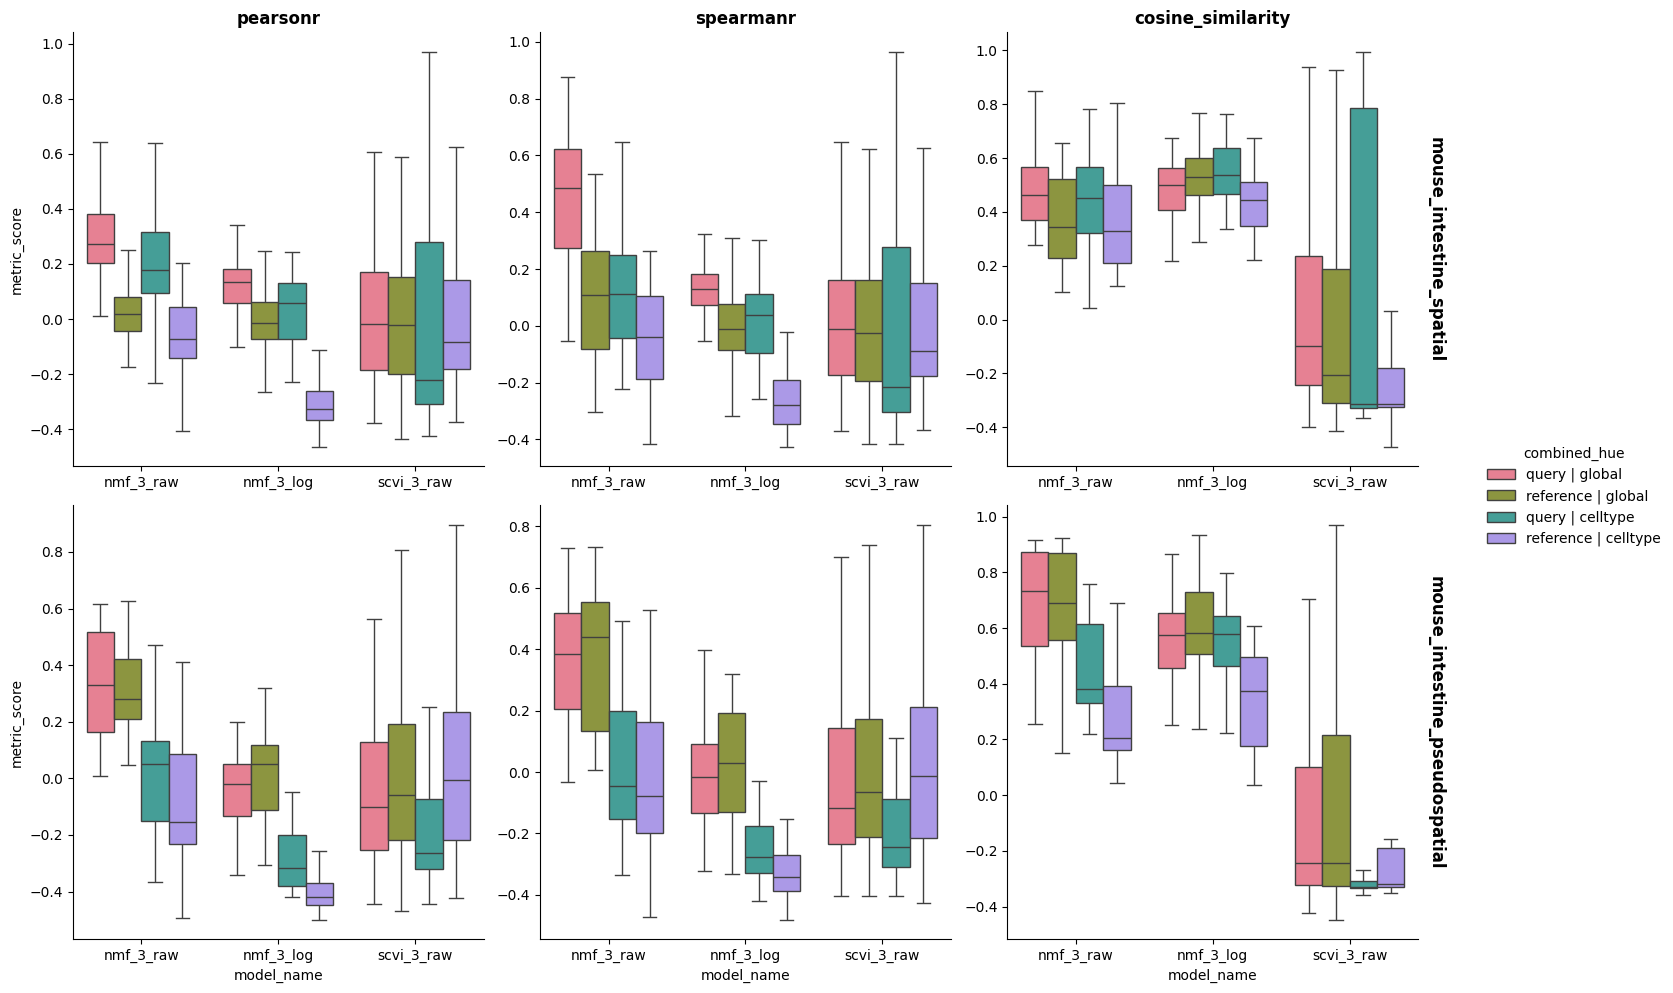

In [ ]:
embedding_autocorrelation_df = embedding_autocorrelation_df.with_columns(
    combined_hue=pl.col("split") + " | " + pl.col("model_scope")
)
sns.catplot(
    data=embedding_autocorrelation_df,
    kind="box",
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    col="metric_name",
    row="dataset_name",
    aspect=1.0,
    sharey=False,
    sharex=False,
    margin_titles=True,
    showfliers=False,
    palette=sns.color_palette("husl", 4),
).set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
    size=12,
    fontweight="bold",
).savefig("embedding_autocorrelations_combined_hue.jpg")

### Cell-Wise Metrics: 2D Array -> float

In [250]:
def gini(arr: NumericArray) -> float:
    """Compute Gini coefficient of a 1D array."""
    if np.amin(arr) < 0:
        arr -= np.amin(arr) # Values must be non-negative
    arr = np.sort(arr)
    index = np.arange(1, arr.shape[0] + 1)
    n = arr.shape[0]
    return float((np.sum((2 * index - n  - 1) * arr)) / (n * np.sum(arr)))

def entropy(arr: NumericArray) -> float:
    return float(scipy.stats.entropy(arr))

def kurtosis(arr: NumericArray) -> float:
    return float(scipy.stats.kurtosis(arr))

def skew(arr: NumericArray) -> float:
    return float(scipy.stats.skew(arr))


def make_aggregate_cellwise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:
    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(np.mean([func(cell) for cell in arr]))

    return aggregate_cellwise_metric_func


DISPERSION_METRIC_FUNC: dict[str, Callable[[NumericArray], float]] = {
    "entropy": entropy,
    "kurtosis": kurtosis,
    "skew": skew,
    "gini": gini
}

In [ ]:
def make_cellwise_metrics_func(
    metrics: dict[str, Callable[[NumericArray], float]],
) -> Callable[[Result], DataEntries]:
    def cellwise_metrics_func(result: Result) -> DataEntries:
        data_entries: DataEntries = []
        for metric_name, metric_func in metrics.items():
            aggregate_cellwise_metric_fn = make_aggregate_cellwise_metric_func(metric_func)
            data_entries.extend(
                [
                    {
                        "model_scope": "global",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.global_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "global",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.global_model_embedding_reference,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.celltype_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.celltype_model_embedding_reference,
                        ),
                    },
                ]
            )
        return data_entries

    return cellwise_metrics_func

In [ ]:
with Session(engine) as session:
    results = session.exec(select(Result)).all()
    cellwise_metric_df = results_to_dataframe(
        results,
        make_cellwise_metrics_func(
            DISPERSION_METRIC_FUNC
        ),
    )

2026-03-11 15:31:39,628 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026/03/11 15:31:39 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-03-11 15:31:39,632 INFO sqlalchemy.engine.Engine SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026/03/11 15:31:39 INFO sqlalchemy.engine.Engine: SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026-03-11 15:31:39,633 INFO sqlalchemy.engine.Engine [cached since 1.472e+04s ago] ()


...

2026/03/11 15:33:48 INFO sqlalchemy.engine.Engine: SELECT celltype.id AS celltype_id, celltype.name AS celltype_name, celltype.reference_counts_matrix AS celltype_reference_counts_matrix, celltype.reference_pca_embedding AS celltype_reference_pca_embedding, celltype.reference_umap_embedding AS celltype_reference_umap_embedding, celltype.reference_adjacency_matrix AS celltype_reference_adjacency_matrix, celltype.query_counts_matrix AS celltype_query_counts_matrix, celltype.query_pca_embedding AS celltype_query_pca_embedding, celltype.query_umap_embedding AS celltype_query_umap_embedding, celltype.query_adjacency_matrix AS celltype_query_adjacency_matrix, celltype.n_pcs AS celltype_n_pcs, celltype.n_neighbours AS celltype_n_neighbours, celltype.dataset_id AS celltype_dataset_id 
FROM celltype 
WHERE celltype.id = ?


2026-03-11 15:33:48,566 INFO sqlalchemy.engine.Engine [cached since 1.484e+04s ago] (38,)


2026/03/11 15:33:48 INFO sqlalchemy.engine.Engine: [cached since 1.484e+04s ago] (38,)


2026-03-11 15:33:48,753 INFO sqlalchemy.engine.Engine ROLLBACK


2026/03/11 15:33:48 INFO sqlalchemy.engine.Engine: ROLLBACK


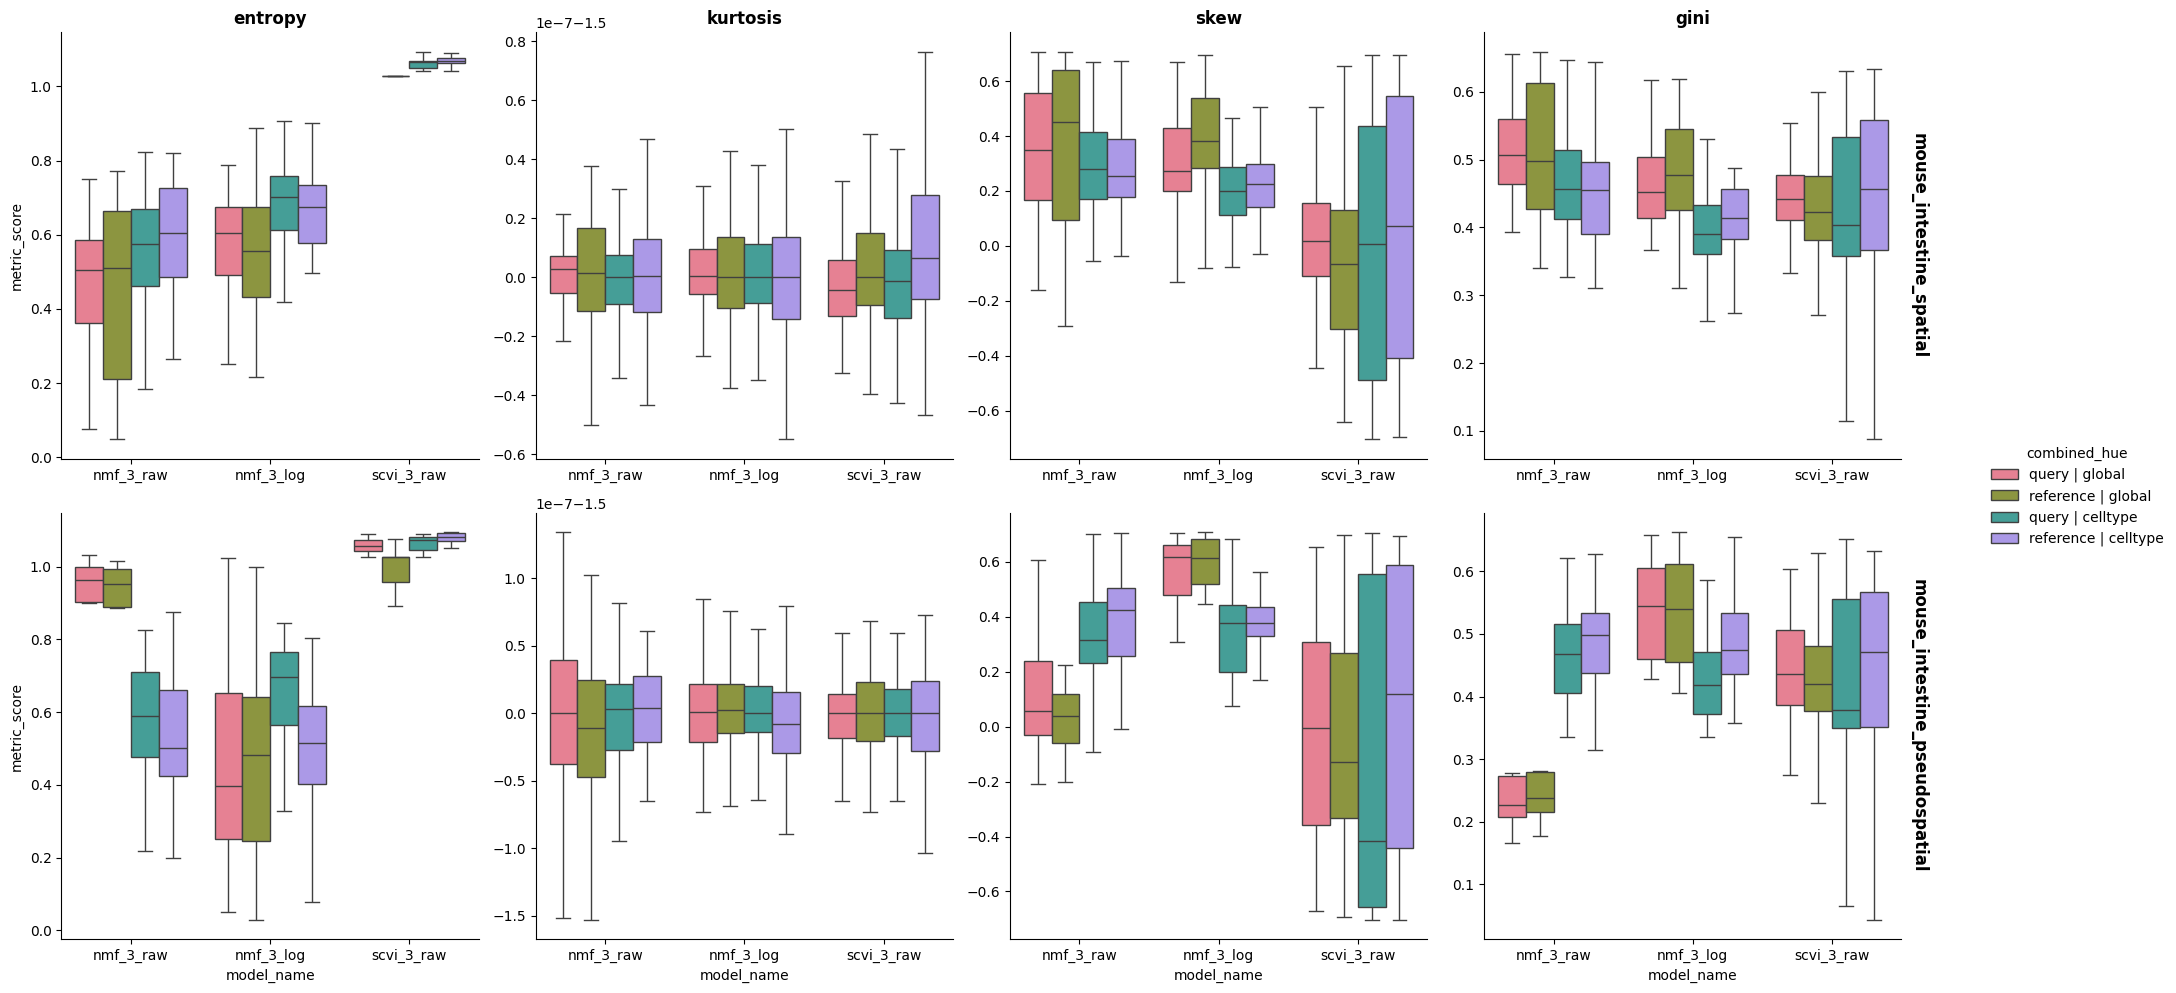

In [242]:
cellwise_metric_df = cellwise_metric_df.with_columns(
    combined_hue=pl.col("split") + " | " + pl.col("model_scope")
)
sns.catplot(
    data=cellwise_metric_df,
    kind="box",
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    col="metric_name",
    row="dataset_name",
    aspect=1.0,
    sharey=False,
    sharex=False,
    margin_titles=True,
    showfliers=False,
    palette=sns.color_palette("husl", 4),
).set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
    size=12,
    fontweight="bold",
).savefig("cellwise_metrics.svg")

In [ ]:
def make_max_aggregate_featurewise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:
    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(func(np.max(arr, axis=1)))
    return aggregate_cellwise_metric_func

In [ ]:
def placeholder(
    metrics: dict[str, Callable[[NumericArray], float]],
) -> Callable[[Result], DataEntries]:
    def cellwise_metrics_func(result: Result) -> DataEntries:
        data_entries: DataEntries = []
        for metric_name, metric_func in metrics.items():
            aggregate_cellwise_metric_fn = make_max_aggregate_featurewise_metric_func(metric_func)
            data_entries.extend(
                [
                    {
                        "model_scope": "global",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.global_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "global",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.global_model_embedding_reference,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "query",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.celltype_model_embedding_query,
                        ),
                    },
                    {
                        "model_scope": "celltype",
                        "split": "reference",
                        "metric_name": metric_name,
                        "metric_score": aggregate_cellwise_metric_fn(
                            result.celltype_model_embedding_reference,
                        ),
                    },
                ]
            )
        return data_entries

    return cellwise_metrics_func

In [251]:
with Session(engine) as session:
    results = session.exec(select(Result)).all()
    max_agg_featurewise_metric_df = results_to_dataframe(
        results,
        placeholder(
            DISPERSION_METRIC_FUNC
        ),
    )

2026-03-11 15:40:36,473 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026/03/11 15:40:36 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-03-11 15:40:36,476 INFO sqlalchemy.engine.Engine SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026/03/11 15:40:36 INFO sqlalchemy.engine.Engine: SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026-03-11 15:40:36,478 INFO sqlalchemy.engine.Engine [cached since 1.526e+04s ago] ()


...

2026/03/11 15:40:38 INFO sqlalchemy.engine.Engine: SELECT celltype.id AS celltype_id, celltype.name AS celltype_name, celltype.reference_counts_matrix AS celltype_reference_counts_matrix, celltype.reference_pca_embedding AS celltype_reference_pca_embedding, celltype.reference_umap_embedding AS celltype_reference_umap_embedding, celltype.reference_adjacency_matrix AS celltype_reference_adjacency_matrix, celltype.query_counts_matrix AS celltype_query_counts_matrix, celltype.query_pca_embedding AS celltype_query_pca_embedding, celltype.query_umap_embedding AS celltype_query_umap_embedding, celltype.query_adjacency_matrix AS celltype_query_adjacency_matrix, celltype.n_pcs AS celltype_n_pcs, celltype.n_neighbours AS celltype_n_neighbours, celltype.dataset_id AS celltype_dataset_id 
FROM celltype 
WHERE celltype.id = ?


2026-03-11 15:40:38,734 INFO sqlalchemy.engine.Engine [cached since 1.526e+04s ago] (38,)


2026/03/11 15:40:38 INFO sqlalchemy.engine.Engine: [cached since 1.526e+04s ago] (38,)


2026-03-11 15:40:38,772 INFO sqlalchemy.engine.Engine ROLLBACK


2026/03/11 15:40:38 INFO sqlalchemy.engine.Engine: ROLLBACK


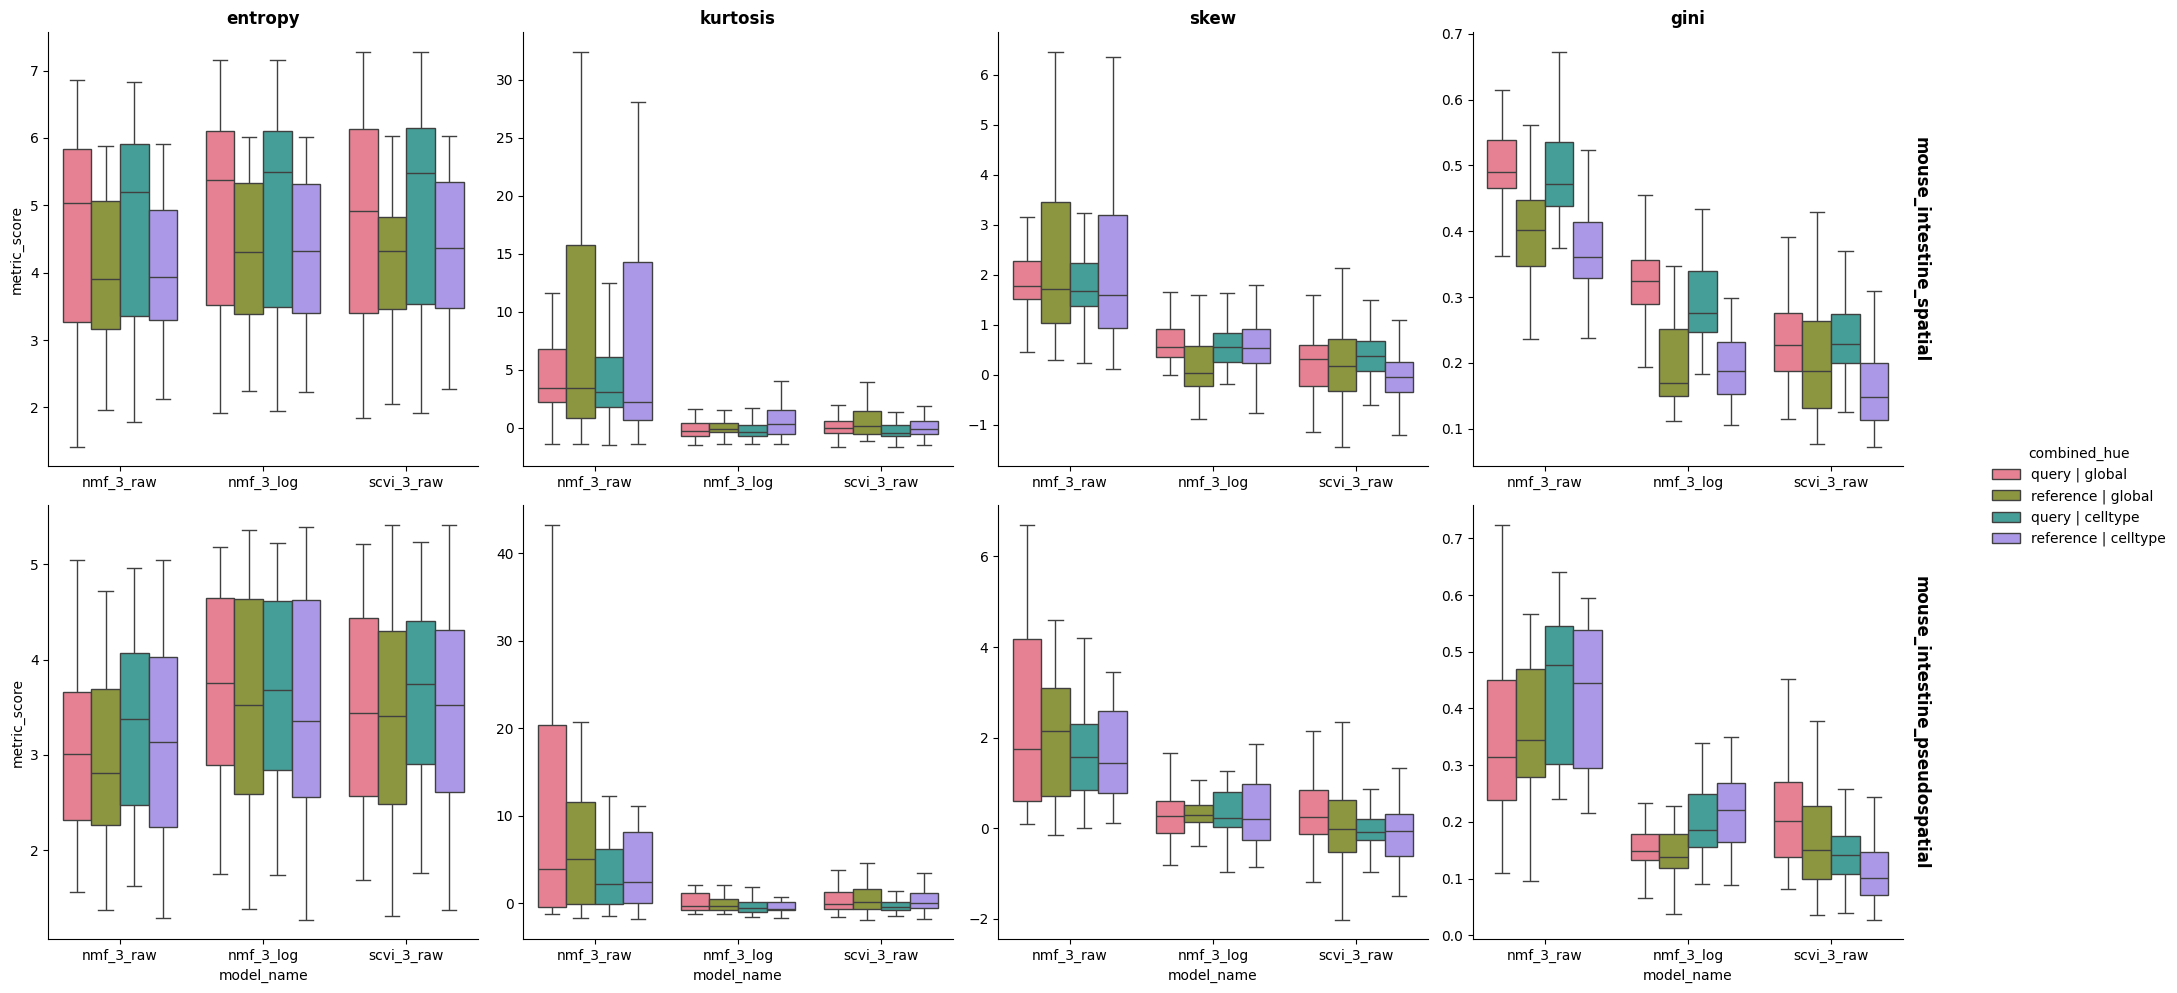

In [252]:
max_agg_featurewise_metric_df = max_agg_featurewise_metric_df.with_columns(
    combined_hue=pl.col("split") + " | " + pl.col("model_scope")
)
sns.catplot(
    data=max_agg_featurewise_metric_df,
    kind="box",
    x="model_name",
    y="metric_score",
    hue="combined_hue",
    col="metric_name",
    row="dataset_name",
    aspect=1.0,
    sharey=False,
    sharex=False,
    margin_titles=True,
    showfliers=False,
    palette=sns.color_palette("husl", 4),
).set_titles(
    row_template="{row_name}",
    col_template="{col_name}",
    size=12,
    fontweight="bold",
).savefig("max_agg_featurewise_metric.svg")